In [1]:
  from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [12]:
cd /content/gdrive/MyDrive/

/content/gdrive/MyDrive


In [3]:
#importa as bibliotecas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
!pip install pdfplumber -q
import pdfplumber
import re #usando
import os #usando
!apt-get install -y tesseract-ocr
!pip install pytesseract
!pip install pillow
import pytesseract
from PIL import Image
!apt-get install -y poppler-utils
!pip install pdf2image
from pdf2image import convert_from_path
import unicodedata
import cv2 #usando
import numpy as np
#biblioteca tdqm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 67.1 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64

In [21]:
main_directory = 'Colab Notebooks/Pesquisa-Comercio'
year_folders = os.listdir(main_directory)
print("Todos os arquivos do diretório principal:", year_folders)

texts = []

def normalizar(texto):
    texto = texto.lower()
    texto = unicodedata.normalize('NFD', texto)
    texto = ''.join(c for c in texto if unicodedata.category(c) != 'Mn')
    return texto

for year_folder in year_folders:
  full_path_of_entry = os.path.join(main_directory, year_folder)

  if os.path.isdir(full_path_of_entry):
    print(f"Processando diretório: {year_folder}")
    contents_of_year_folder = os.listdir(full_path_of_entry)
    print(f"Conteúdo do '{year_folder}': {contents_of_year_folder}")

    for  eachFile in contents_of_year_folder:
      full_path_of_contents_of_year_folder = os.path.join( full_path_of_entry,eachFile )
      print(eachFile)

      with pdfplumber.open(full_path_of_contents_of_year_folder) as pdf:
        for i, page in enumerate(pdf.pages):

          text_pages = page.extract_text()

          if text_pages and len(text_pages.strip()) > 30:
            text_limpo = normalizar(text_pages)

            if "minas gerais" in text_limpo and "atividades de divulg"  in text_limpo and "tabela 4" in text_limpo:
              texts.append(text_pages)
              break
          #print(repr(text_pages))
          #print(len(pages))

          else:
                images = convert_from_path(full_path_of_contents_of_year_folder, first_page=i + 1, last_page=i + 1)
                img = images[0]
                img_np = np.array(img)

                # converter pra escala de cinza
                gray = cv2.cvtColor(img_np, cv2.COLOR_BGR2GRAY)

                # aumentar contraste (muito importante)
                _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

                # OCR com configuração melhor
                text = pytesseract.image_to_string(thresh, config='--psm 6')


                if eachFile == "pmc_2021_mar.pdf":
                  print("OCR:", repr(text)) #testar essa parte

                if text and len(text.strip()) > 30: #strip tira os espaços
                  text_ocr_clean = normalizar(text)

                  if "minas gerais" in text_ocr_clean and "atividades de divulg"  in text_ocr_clean and "tabela 4" in text_ocr_clean:
                    texts.append(text)
                    break


  elif os.path.isfile(full_path_of_entry):
    print(f"Arquivo ignorado: {year_folder}")

print(len(texts))


print(f"Last entry name processed (or attempted): {year_folder}")

Todos os arquivos do diretório principal: ['2020', '2021', '2025', '2024', '2023', '2022']
Processando diretório: 2020
Conteúdo do '2020': ['pmc_2020_dez.pdf', 'pmc_2020_jun.pdf', 'pmc_2020_mar.pdf', 'pmc_2020_set.pdf']
pmc_2020_dez.pdf
pmc_2020_jun.pdf
pmc_2020_mar.pdf
pmc_2020_set.pdf
Processando diretório: 2021
Conteúdo do '2021': ['pmc_2021_set.pdf', 'pmc_2021_mar.pdf', 'pmc_2021_dez.pdf', 'pmc_2021_jun.pdf']
pmc_2021_set.pdf
pmc_2021_mar.pdf
OCR: 'TABELAS\n1\n\x0c'
OCR: 'Pesquisa Mensal de Comércio\nTabela 1 - Indicadares do Volume de Vendas do Comércia Varejista e Comércio Varejista Ampliado, segundo as atividades de divulgacao\nMargo 2021 - Variagao (%)\nMés/Més anterior (1) Mensal (2) Acumulado no ano (3) Ultimos 12 meses (4}\nAtividades de Divulgaga\nComeércio varejista (5) -0,2 0,5 0,6 0,4 3,9 24 -0,4 -2,1 -0,6 1,0 0,4 0,7\n1. Combustiveis e lubrificantes 0,1 -0,8 5,3 -7,8 -10,7 -1,5 -7,8 -9,2 6,8 -10,3 -11,2 -10,5\n2. Hipermercados, supermercados, produtos alimenticios bebid

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [14]:
print(texts)

['Pesquisa Mensal de Comércio\nTabela 4 - Indicadores do Volume de Vendas do Comércio Varejista e Comércio Varejista Ampliado, segundo atividades de divulgação\nMinas Gerais - Dezembro 2020 - Variação (%)\nMensal (1) Acumulado no ano (2) Últimos 12 meses (3)\nAtividades de Divulgação\nOUT NOV DEZ JAN-OUT JAN-NOV JAN-DEZ Até OUT Até NOV Até DEZ\nComércio Varejista (4) 12,3 5,8 3,4 3,2 3,5 3,5 3,1 3,4 3,5\n1. Combustíveis e lubrificantes 1,8 2,9 4,6 -8,6 -7,6 -6,6 -7,8 -7,4 -6,6\n2. Hipermercados, supermercados, produtos alimentícios bebidas e fumo 8,0 -0,8 4,6 4,9 4,4 4,4 3,7 3,5 4,4\n2.1. Hipermercados e supermercados 9,6 -0,4 4,9 6,3 5,7 5,6 4,9 4,7 5,6\n3. Tecidos, vestuário e calçados 7,3 36,9 -1,3 -14,3 -9,4 -8,2 -9,8 -7,1 -8,2\n4. Móveis e eletrodomésticos 17,8 6,7 -3,2 4,5 4,8 3,9 4,9 5,8 3,9\n5. Artigos farmacêuticos, médicos, ortopédicos, de perfumaria e cosméticos 15,5 17,8 22,2 11,3 12,0 12,9 11,0 11,8 12,9\n6. Livros, jornais, revistas e papelaria -33,3 -29,3 -34,0 -32,9 -32

In [15]:
linhaDesejada = []
palavra_chave = normalizar("farmacêuticos")

for pag in texts:
  #print("NOVA PÁGINA")
  linhas = pag.split('\n') #Divide o texto em uma lista de linhas

  for linha in linhas:
    linha_limpa = normalizar(linha)
    if palavra_chave in linha_limpa:
      #print("LINHA ENCONTRADA:", linha, "\n")
      linhaDesejada.append(linha)
      break

print(linhaDesejada)

dados_re_pattern = (r'[-+]?\d+[.,]?\d+')
dados = []
for info in linhaDesejada:
  match_dado = re.findall(dados_re_pattern, info)
  for dado in match_dado:
    dados.append(float(dado.replace(',','.')))

print(dados)

['5. Artigos farmacêuticos, médicos, ortopédicos, de perfumaria e cosméticos 15,5 17,8 22,2 11,3 12,0 12,9 11,0 11,8 12,9', '5. Artigos farmacêuticos, médicos, ortopédicos, de perfumaria e cosméticos -1,2 0,4 16,3 8,4 6,6 8,2 9,7 8,4 8,9', '5. Artigos farmacêuticos, médicos, ortopédicos, de perfumaria e cosméticos 8,8 10,7 15,3 8,8 9,7 11,7 10,0 9,8 10,6', '5. Artigos farmacêuticos, médicos, ortopédicos, de perfumaria e cosméticos 15,6 13,7 18,0 9,4 9,9 10,9 9,2 9,7 10,5', '5. Artigos farmacêuticos, médicos, ortopédicos, de perfumaria e cosméticos 17,1 19,1 16,6 23,6 23,0 22,2 21,1 21,5 21,3', '5. Artigos farmacéuticos, médicos, ortopédicos, de perfumaria e cosméticos 23,8 16,1 20,8 23,8 20,0 20,3 14,2 14,6 15,1', '5. Artigos farmacêuticos, médicos, ortopédicos, de perfumaria e cosméticos 14,2 20,3 15,7 21,3 21,2 20,6 21,2 21,3 20,6', '5. Artigos farmacêuticos, médicos, ortopédicos, de perfumaria e cosméticos 35,8 31,4 20,6 23,9 25,5 24,6 18,0 20,6 20,9', '5. Artigos farmacêuticos, méd

In [16]:
# Cria sublistas de 3 elementos
n = 3

sublistas = [dados[i:i + n] for i in range(0, len(dados), n)]
print(sublistas)

[[15.5, 17.8, 22.2], [11.3, 12.0, 12.9], [11.0, 11.8, 12.9], [-1.2, 0.4, 16.3], [8.4, 6.6, 8.2], [9.7, 8.4, 8.9], [8.8, 10.7, 15.3], [8.8, 9.7, 11.7], [10.0, 9.8, 10.6], [15.6, 13.7, 18.0], [9.4, 9.9, 10.9], [9.2, 9.7, 10.5], [17.1, 19.1, 16.6], [23.6, 23.0, 22.2], [21.1, 21.5, 21.3], [23.8, 16.1, 20.8], [23.8, 20.0, 20.3], [14.2, 14.6, 15.1], [14.2, 20.3, 15.7], [21.3, 21.2, 20.6], [21.2, 21.3, 20.6], [35.8, 31.4, 20.6], [23.9, 25.5, 24.6], [18.0, 20.6, 20.9], [0.2, 12.2, 2.9], [-0.1, 2.5, 2.6], [3.4, 4.0, 3.5], [20.6, 18.3, 10.2], [8.3, 9.3, 9.3], [6.9, 8.3, 9.3], [11.2, 10.6, 13.8], [3.9, 4.7, 5.7], [3.6, 4.0, 4.5], [2.4, 0.6, -3.2], [2.4, 1.5, -0.2], [6.9, 5.8, 4.6], [10.3, 20.4, 15.0], [10.3, 15.2, 15.2], [10.3, 11.3, 11.7], [20.9, 9.7, 13.6], [16.6, 15.0, 14.8], [12.5, 12.1, 12.9], [9.9, 5.2, 1.8], [13.7, 12.8, 11.7], [14.3, 13.1, 11.7], [15.2, 11.3, 4.0], [14.8, 14.4, 13.1], [13.8, 14.4, 13.8], [10.1, 14.6, 4.2], [6.6, 8.3, 7.6], [13.9, 13.8, 12.2], [13.0, 17.9, 16.4], [7.8, 8.7

In [17]:
#filtra só os dados que eu quero
dados_desejados = []
i=0

for i in range(0,len(sublistas),3):
  dados_desejados.append(sublistas[i])

print(dados_desejados)

[[15.5, 17.8, 22.2], [-1.2, 0.4, 16.3], [8.8, 10.7, 15.3], [15.6, 13.7, 18.0], [17.1, 19.1, 16.6], [23.8, 16.1, 20.8], [14.2, 20.3, 15.7], [35.8, 31.4, 20.6], [0.2, 12.2, 2.9], [20.6, 18.3, 10.2], [11.2, 10.6, 13.8], [2.4, 0.6, -3.2], [10.3, 20.4, 15.0], [20.9, 9.7, 13.6], [9.9, 5.2, 1.8], [15.2, 11.3, 4.0], [10.1, 14.6, 4.2], [13.0, 17.9, 16.4], [-0.4, 5.9, 9.8], [4.5, 4.0, 3.1], [23.0, 6.4, 9.3], [18.8, 23.0, 24.7], [11.3, 15.5, 22.8], [21.8, 21.8, 17.0]]


In [18]:
dados_organizados = []
for i in range(0,len(dados_desejados), 4):
  agrupamento = dados_desejados[i:i+4]
  grupo = []
  for sublist in agrupamento:
    grupo.extend(sublist)
  dados_organizados.append(grupo)
dados_organizados.insert(0, ["jan", "fev", "mar", "abr", "mai", "jun", "jul", "ago", "set", "out", "nov", "dez"] )

print(dados_organizados)

[['jan', 'fev', 'mar', 'abr', 'mai', 'jun', 'jul', 'ago', 'set', 'out', 'nov', 'dez'], [15.5, 17.8, 22.2, -1.2, 0.4, 16.3, 8.8, 10.7, 15.3, 15.6, 13.7, 18.0], [17.1, 19.1, 16.6, 23.8, 16.1, 20.8, 14.2, 20.3, 15.7, 35.8, 31.4, 20.6], [0.2, 12.2, 2.9, 20.6, 18.3, 10.2, 11.2, 10.6, 13.8, 2.4, 0.6, -3.2], [10.3, 20.4, 15.0, 20.9, 9.7, 13.6, 9.9, 5.2, 1.8, 15.2, 11.3, 4.0], [10.1, 14.6, 4.2, 13.0, 17.9, 16.4, -0.4, 5.9, 9.8, 4.5, 4.0, 3.1], [23.0, 6.4, 9.3, 18.8, 23.0, 24.7, 11.3, 15.5, 22.8, 21.8, 21.8, 17.0]]


In [19]:
df = pd.DataFrame(dados_organizados[1:], columns=dados_organizados[0])
df.index = [2025,2024,2023,2022,2021,2020]
df

,jan,fev,mar,abr,mai,jun,jul,ago,set,out,nov,dez
2025,15.5,17.8,22.2,-1.2,0.4,16.3,8.8,10.7,15.3,15.6,13.7,18.0
2024,17.1,19.1,16.6,23.8,16.1,20.8,14.2,20.3,15.7,35.8,31.4,20.6
2023,0.2,12.2,2.9,20.6,18.3,10.2,11.2,10.6,13.8,2.4,0.6,-3.2
2022,10.3,20.4,15.0,20.9,9.7,13.6,9.9,5.2,1.8,15.2,11.3,4.0
2021,10.1,14.6,4.2,13.0,17.9,16.4,-0.4,5.9,9.8,4.5,4.0,3.1
2020,23.0,6.4,9.3,18.8,23.0,24.7,11.3,15.5,22.8,21.8,21.8,17.0


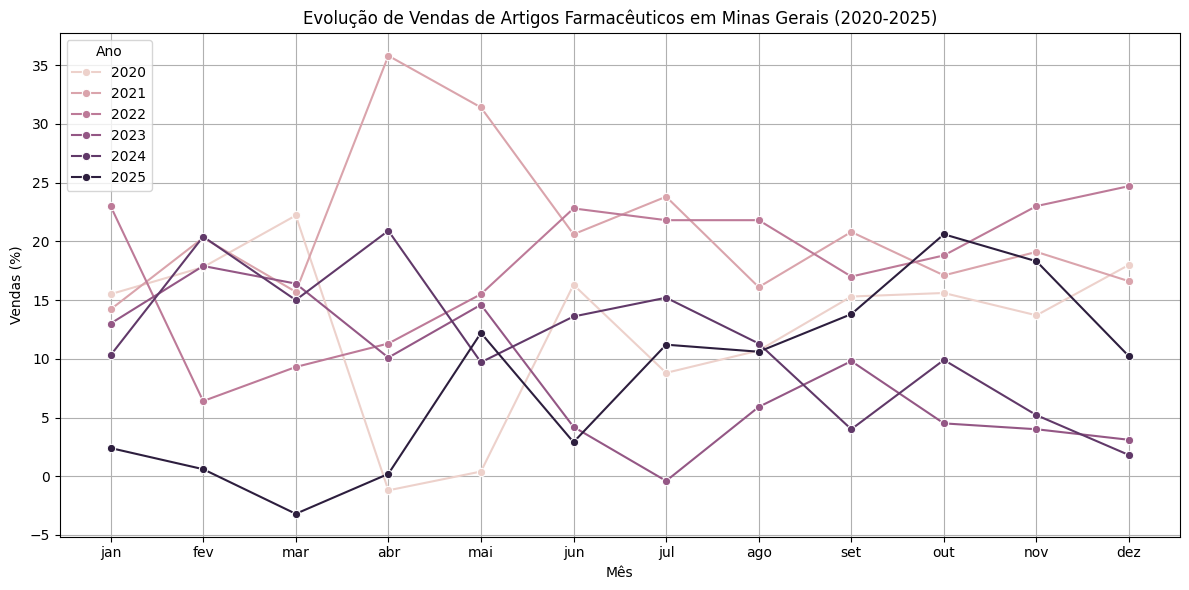

In [ ]:
df_reset = df.reset_index()
df_reset = df_reset.rename(columns={'index': 'Ano'})

df_melted = pd.melt(df_reset, id_vars=['Ano'], var_name='Mes', value_name='Vendas')

# Ordem correta dos meses para o plot
month_order = ['jan', 'fev', 'mar', 'abr', 'mai', 'jun', 'jul', 'ago', 'set', 'out', 'nov', 'dez']
df_melted['Mes'] = pd.Categorical(df_melted['Mes'], categories=month_order, ordered=True)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_melted, x='Mes', y='Vendas', hue='Ano', marker='o')
plt.title('Evolução de Vendas de Artigos Farmacêuticos em Minas Gerais (2020-2025)')
plt.xlabel('Mês')
plt.ylabel('Vendas (%)')
plt.grid(True)
plt.legend(title='Ano')
plt.tight_layout()
plt.show()

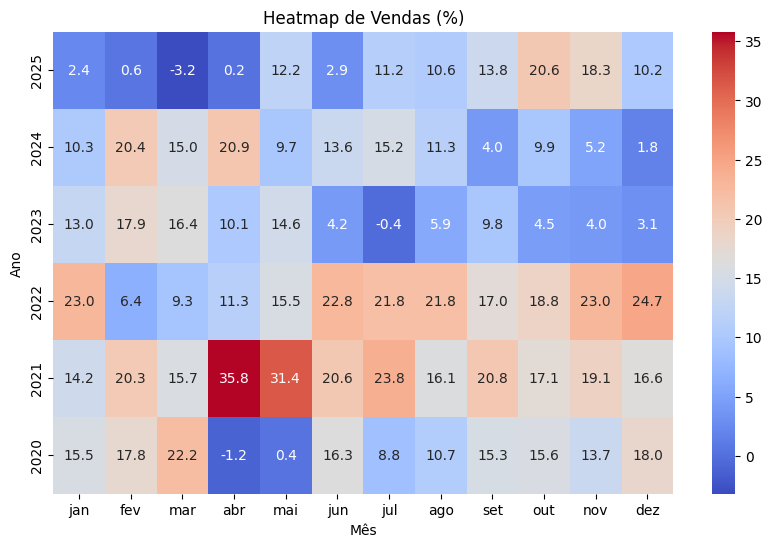

In [ ]:
df = pd.DataFrame(dados_organizados[1:], columns=dados_organizados[0])
df.index = [2025,2024,2023,2022,2021,2020]

plt.figure(figsize=(10,6))
sns.heatmap(df, annot=True, cmap='coolwarm', fmt=".1f")
plt.title("Heatmap de Vendas (%)")
plt.xlabel("Mês")
plt.ylabel("Ano")
plt.show()

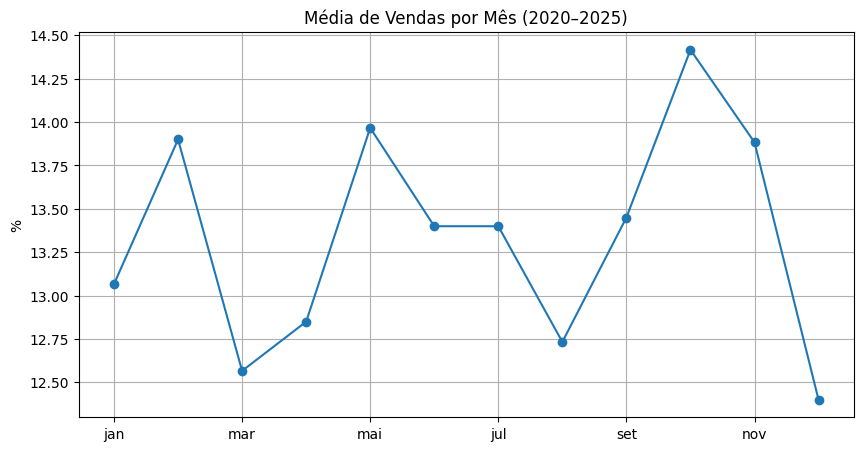

In [ ]:
media_mensal = df.mean()

plt.figure(figsize=(10,5))
media_mensal.plot(marker='o')
plt.title("Média de Vendas por Mês (2020–2025)")
plt.ylabel("%")
plt.grid()
plt.show()

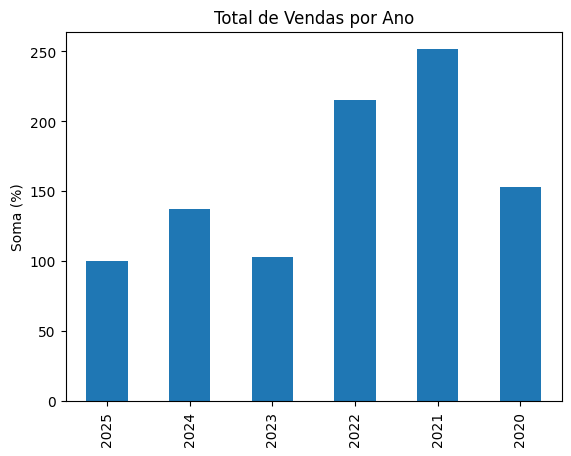

In [ ]:
total_ano = df.sum(axis=1)

total_ano.plot(kind='bar')
plt.title("Total de Vendas por Ano")
plt.ylabel("Soma (%)")
plt.show()

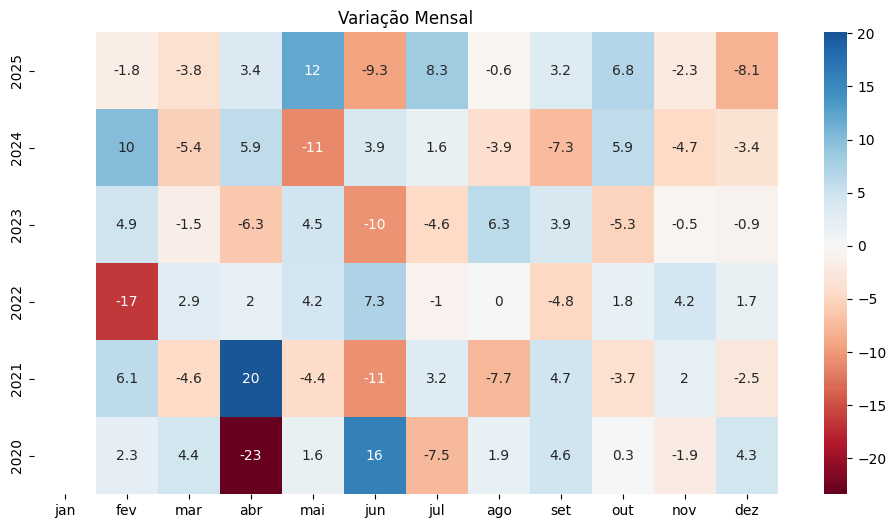

In [ ]:
df_diff = df.diff(axis=1)

plt.figure(figsize=(12,6))
sns.heatmap(df_diff, annot=True, cmap='RdBu', center=0)
plt.title("Variação Mensal")
plt.show()

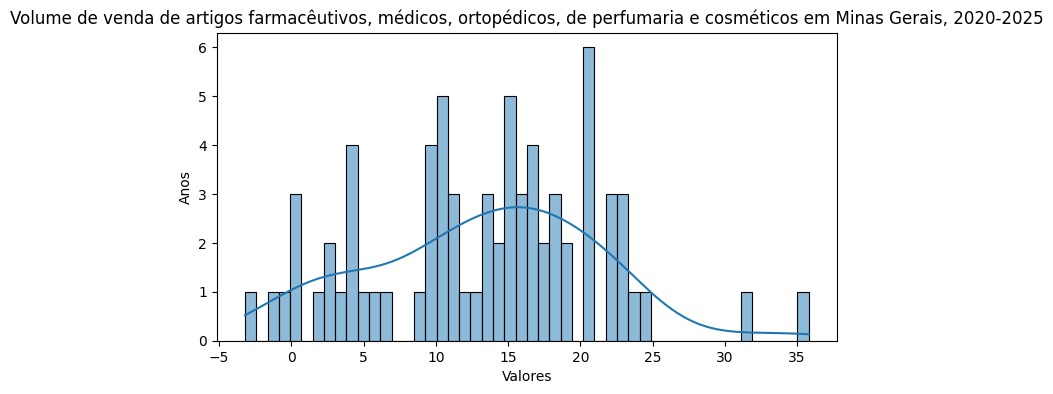

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df.values.flatten(), bins=50, kde=True)#BEANS=define os intervalos entre as barras que serão geradas pelo histograma
#KDE= é uma linha que vai ser adicionado no gráfico para entendermos como está a distribuição de uma forma mais fácil de visualizar
plt.title('Volume de venda de artigos farmacêutivos, médicos, ortopédicos, de perfumaria e cosméticos em Minas Gerais, 2020-2025')
plt.xlabel('Valores')
plt.ylabel('Anos')
plt.show()